##### 코랩을 사용할 경우

In [ ]:
try:
    # Google Drive를 Colab(/content/drive)에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # Colab에서 작업 디렉토리로 이동
    %cd /google_drive/Othercomputers/'내 컴퓨터'/sec05
    %ls
except ImportError:
    pass

##### 임포트

In [1]:
import torch
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt

##### Device 설정

In [2]:
# GPU(CUDA) 사용 가능 시 'cuda', 아니면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cpu


##### 데이터 로드

In [3]:
# Wine 데이터셋 로드
wine = load_wine()

# 데이터셋 설명 출력
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

##### 데이터 분석

In [4]:
# 데이터셋 구조 확인
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [5]:
print(f"- 데이터 형태: {wine.data.shape} {type(wine.data)}")        # (샘플수, 특성수)
print(f"- 데이터 특성: {wine.feature_names}")                       # 특성 이름
print(f"- 레이블 형태: {wine.target.shape} {type(wine.target)}")    # 정답
print(f"- 레이블 이름: {wine.target_names}")                        # 와인명이 아니라 클래스명임

- 데이터 형태: (178, 13) <class 'numpy.ndarray'>
- 데이터 특성: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
- 레이블 형태: (178,) <class 'numpy.ndarray'>
- 레이블 이름: ['class_0' 'class_1' 'class_2']


##### 판다스 데이터프레임으로 변환

In [6]:
# 판다스 데이터프레임으로 변환
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


##### 결측값 존재 여부 확인

In [7]:
# 특성별 결측값 개수 확인
missing_by_feature = df.isna().sum()
print(missing_by_feature)

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64


##### 클래스(레이블)별 샘플 수

In [8]:
df['target'].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

class_0: 59개
class_1: 71개
class_2: 48개


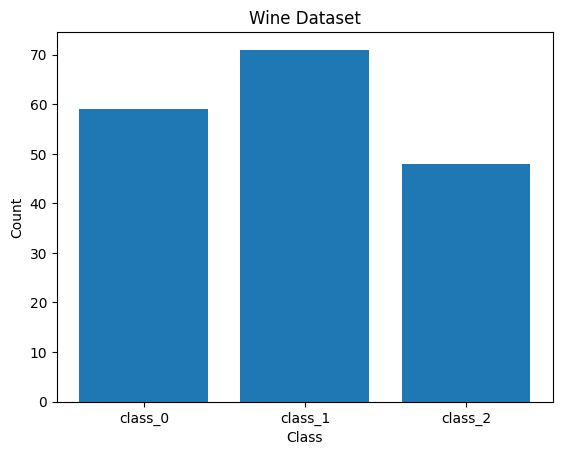

In [9]:
# 레이블(클래스)별 샘플 수
class_counts = df['target'].value_counts().sort_index()
for idx, count in class_counts.items():
    print(f"{wine.target_names[idx]}: {count}개")

# # 데이터셋 시각화 방법1
# axes = class_counts.plot(kind='bar')
# axes.set_title('Wine Dataset')
# axes.set_xlabel('Class')
# axes.set_xticks(ticks=range(3), labels=wine.target_names, rotation=0)
# axes.set_ylabel('Count')
# axes.bar(class_counts.index, class_counts.values)

# 데이터셋 시각화 방법2
plt.figure()
axes = plt.gca()
axes.set_title('Wine Dataset')
axes.set_xlabel('Class')
axes.set_xticks(ticks=range(3), labels=wine.target_names)
axes.set_ylabel('Count')
axes.bar(class_counts.index, class_counts.values)

plt.show()


##### 훈련/검증/평가 데이터셋 만들기

In [10]:
# ==============================================================
# 데이터셋 분할 전략
#   전체 178개
#     ├─ 훈련셋  (train)      : 142개 (약 80%)
#     │    → 모델 파라미터 업데이트에 사용
#     ├─ 검증셋  (validation) :  18개 (약 10%)
#     │    → 에포크마다 과적합 여부 확인에 사용, 향후 조기 종료 및 하이퍼파라미터 튜닝에 사용
#     └─ 테스트셋 (test)      :  18개 (약 10%)
#          → 학습 완료 후 최종 성능 평가에만 사용
# ==============================================================

# 1. DataFrame 생성 및 target 컬럼 추가
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# 2. 특성 데이터 표준화 (평균 0, 표준편차 1)
# - 피처별 평균=0, 표준편차=1로 표준화
# - Wine 데이터셋은 피처 스케일이 크게 다름 (proline: 278~1680, malic_acid: 0.7~5.8)
# - 표준화하지 않으면 피처 스케일 차이로 인해 옵티마이저(경사하강법 기반)가 제대로 수렴하지 않아 학습이 안 됨
# - 어떤 특성의 표준편차가 0에 가까우면 값이 과도하게 커질 수 있음, 1e-8을 더해주므로서 완화시킴, 원래 값에 미치는 영향은 거의 없음
original_df = df[wine.feature_names]
standardized_df = (original_df - original_df.mean()) / (original_df.std() + 1e-8)

# 3. target 컬럼 추가
standardized_df['target'] = wine.target

# 4. 분할: 먼저 훈련용(80%)를 떼어내고, 나머지에서 검증용(50%), 평가용(50%)을 분리
# - random_state를 지정하면, 동일한 난수 시드로 인해 항상 동일한 샘플이 선택됨
train_df  = standardized_df.sample(frac=0.8, random_state=42)
remain_df   = standardized_df.drop(index=train_df.index)
val_df   = remain_df.sample(frac=0.5, random_state=42)
test_df = remain_df.drop(index=val_df.index)

# 5. 텐서로 변환
# - wine.data는 기본적으로 float64 (numpy의 기본 타입)
# - PyTorch 모델의 가중치 타입은 torch.float32 타입이므로, 입력 데이터도 같은 타입으로 변환
# - 손실 함수(CrossEntropyLoss)는 정답 레이블 요소 타입으로 torch.long 타입으로 요구
train_x_tensor = torch.tensor(train_df.drop(columns=['target']).values, 
                              dtype=torch.float32, 
                              device=device)
train_y_tensor = torch.tensor(train_df['target'].values, 
                              dtype=torch.long, 
                              device=device)

val_x_tensor   = torch.tensor(val_df.drop(columns=['target']).values, 
                              dtype=torch.float32, 
                              device=device)
val_y_tensor   = torch.tensor(val_df['target'].values,   
                              dtype=torch.long, 
                              device=device)

test_x_tensor  = torch.tensor(test_df.drop(columns=['target']).values, 
                              dtype=torch.float32, 
                              device=device)
test_y_tensor  = torch.tensor(test_df['target'].values,  
                              dtype=torch.long, 
                              device=device)


print(f"- 훈련: {len(train_x_tensor)}개"
      f"(품종A {(train_y_tensor==0).sum().item()}개, "
      f"품종B {(train_y_tensor==1).sum().item()}개, "
      f"품종C {(train_y_tensor==2).sum().item()}개)")

print(f"- 검증: {len(val_x_tensor)}개"
      f"(품종A {(val_y_tensor==0).sum().item()}개, "
      f"품종B {(val_y_tensor==1).sum().item()}개, "
      f"품종C {(val_y_tensor==2).sum().item()}개)")

print(f"- 평가: {len(test_x_tensor)}개"
      f"(품종A {(test_y_tensor==0).sum().item()}개, "
      f"품종B {(test_y_tensor==1).sum().item()}개, "
      f"품종C {(test_y_tensor==2).sum().item()}개)")


- 훈련: 142개(품종A 48개, 품종B 57개, 품종C 37개)
- 검증: 18개(품종A 5개, 품종B 7개, 품종C 6개)
- 평가: 18개(품종A 6개, 품종B 7개, 품종C 5개)
